In [31]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [32]:
scores = np.load("/content/feature_importances.npy")
idx = np.load("/content/feature_ranking_idx.npy")

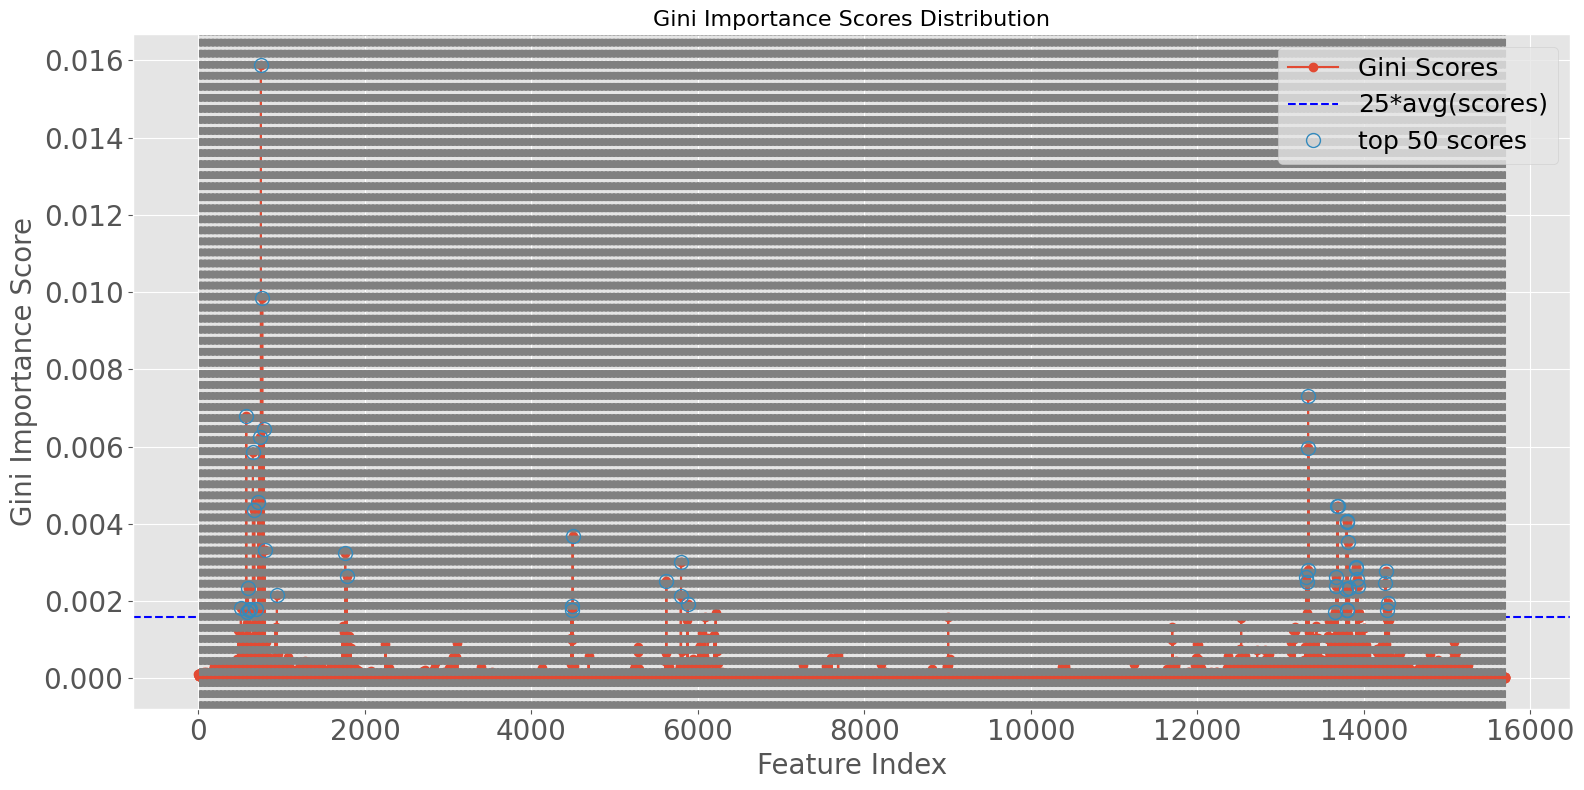

In [35]:
plt.figure(figsize=(16,8))
plt.plot(scores, "-o", label="Gini Scores")
plt.axhline(25*np.mean(scores), color="blue", linestyle='--', label="25*avg(scores)")
for i in range(981):
  plt.axvline(16*(i+1), color="gray", linestyle='--')
plt.plot(
    idx[:50],
    np.sort(scores)[::-1][:50],
    'o',
    markersize=10,
    markeredgewidth=1,
    markerfacecolor='none',
    label="top 50 scores"
)
plt.title("Gini Importance Scores Distribution", fontsize=16)
plt.xlabel("Feature Index", fontsize=20)
plt.ylabel("Gini Importance Score", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()

In [36]:
all_scores = []
for i in range(981):
  score = scores[(i)*16:(i+1)*16]
  all_scores.append(score)
all_scores = np.array(all_scores)

In [37]:
len(np.sum(all_scores, axis=0))

16

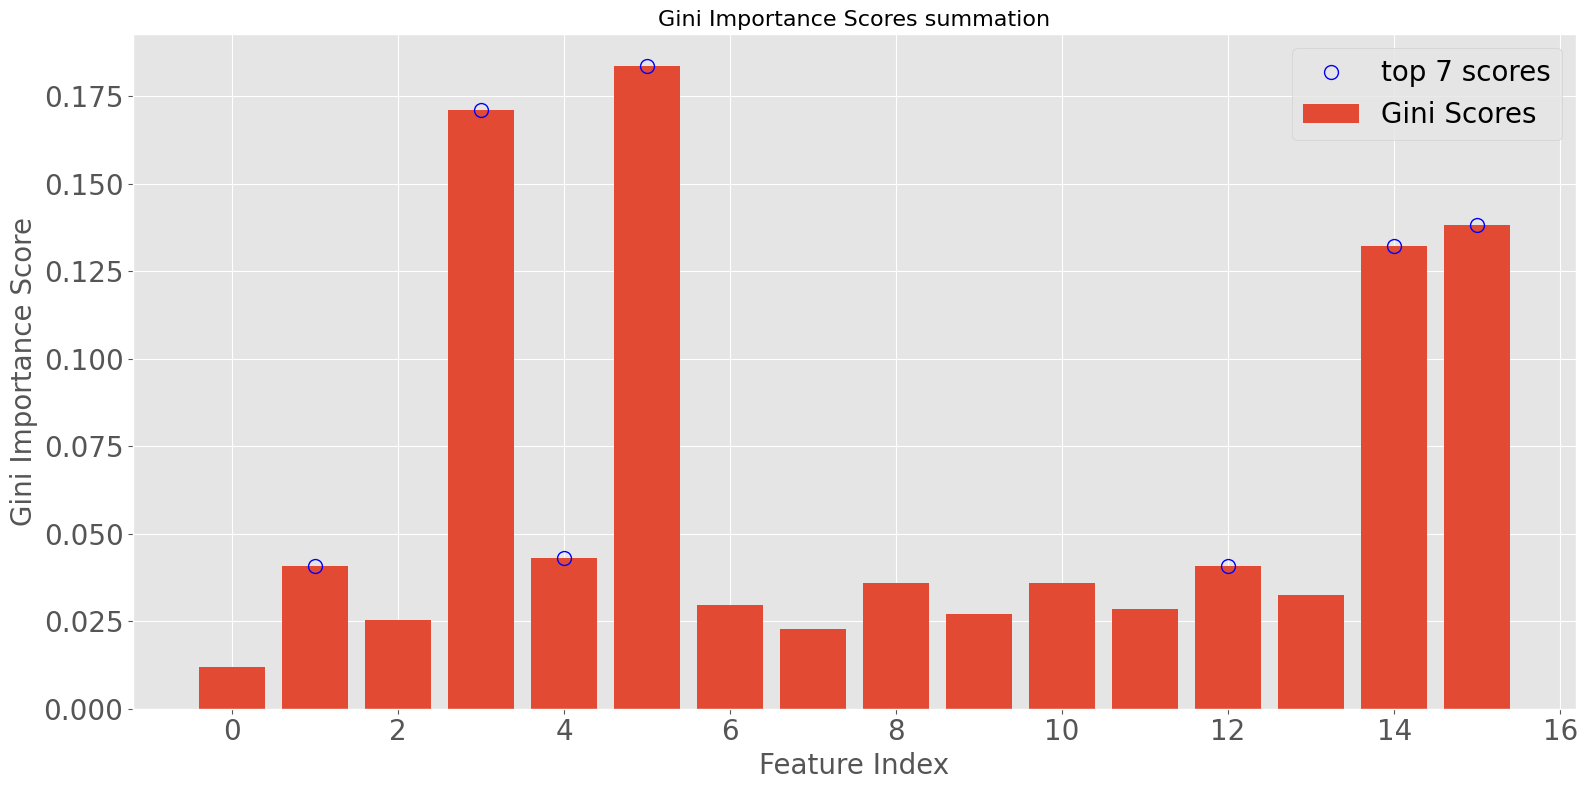

In [38]:
plt.figure(figsize=(16,8))

plt.bar(np.arange(16), np.sum(all_scores, axis=0), label="Gini Scores")

plt.plot(
    np.argsort(np.sum(all_scores, axis=0))[::-1][:7],
    np.sort(np.sum(all_scores, axis=0))[::-1][:7],
    'o',
    markersize=10,
    markeredgewidth=1,
    markerfacecolor='none',
    label="top 7 scores",
    color='blue'
)
plt.title("Gini Importance Scores summation", fontsize=16)
plt.xlabel("Feature Index", fontsize=20)
plt.ylabel("Gini Importance Score", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()

per sensor scores

In [39]:
import pandas as pd

f_values= np.linspace(1000, 50000, 981)
df = pd.DataFrame()
df["indices"] = np.arange(16)
for i, f in enumerate(f_values):
  df[f"scores_{int(f)}"] = scores[(i)*16:(i+1)*16]

/tmp/ipython-input-1705638099.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"scores_{int(f)}"] = scores[(i)*16:(i+1)*16]
/tmp/ipython-input-1705638099.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"scores_{int(f)}"] = scores[(i)*16:(i+1)*16]
/tmp/ipython-input-1705638099.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmen

In [40]:
df.describe()

,indices,scores_1000,scores_1050,scores_1100,scores_1150,scores_1200,scores_1250,scores_1300,scores_1350,scores_1400,...,scores_49550,scores_49600,scores_49650,scores_49700,scores_49750,scores_49800,scores_49850,scores_49900,scores_49950,scores_50000
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,...,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,7.500000,0.000090,0.000084,0.000081,0.000083,0.000099,0.000099,0.000091,0.000088,0.000098,...,0.000027,0.000030,0.000032,0.000028,0.000024,0.000024,0.000025,0.000025,0.000022,0.000021
std,4.760952,0.000021,0.000020,0.000020,0.000019,0.000032,0.000029,0.000029,0.000015,0.000019,...,0.000015,0.000014,0.000016,0.000014,0.000011,0.000012,0.000011,0.000012,0.000008,0.000009
min,0.000000,0.000057,0.000060,0.000043,0.000052,0.000062,0.000064,0.000053,0.000056,0.000064,...,0.000007,0.000007,0.000008,0.000008,0.000008,0.000006,0.000009,0.000008,0.000007,0.000007
25%,3.750000,0.000081,0.000068,0.000066,0.000065,0.000077,0.000080,0.000063,0.000080,0.000089,...,0.000021,0.000019,0.000020,0.000019,0.000017,0.000017,0.000018,0.000019,0.000017,0.000017
50%,7.500000,0.000096,0.000083,0.000083,0.000084,0.000085,0.000098,0.000091,0.000090,0.000098,...,0.000022,0.000028,0.000025,0.000025,0.000021,0.000021,0.000023,0.000022,0.000022,0.000020
75%,11.250000,0.000106,0.000097,0.000090,0.000094,0.000130,0.000106,0.000107,0.000095,0.000108,...,0.000026,0.000045,0.000048,0.000034,0.000030,0.000028,0.000030,0.000028,0.000026,0.000024
max,15.000000,0.000116,0.000133,0.000122,0.000116,0.000153,0.000164,0.000148,0.000115,0.000141,...,0.000062,0.000054,0.000059,0.000060,0.000048,0.000049,0.000049,0.000052,0.000035,0.000039


In [41]:
# select score columns
score_cols = [c for c in df.columns if c.startswith("scores_")]

# mean score per frequency (column-wise)
mean_scores = df[score_cols].mean(axis=0)

# sort from high to low
mean_scores_sorted = mean_scores.sort_values(ascending=False)

# mean_scores_sorted

In [42]:
best_frequencies = mean_scores_sorted.index.str.replace("scores_", "").astype(int)
# best_frequencies

In [43]:
# plt.plot(np.sort(best_frequencies), mean_scores_sorted, "o-")
test_df = pd.DataFrame()
test_df['freq'] = best_frequencies
test_df["mean"] = mean_scores_sorted.values
test_df = test_df.sort_values(by="freq")

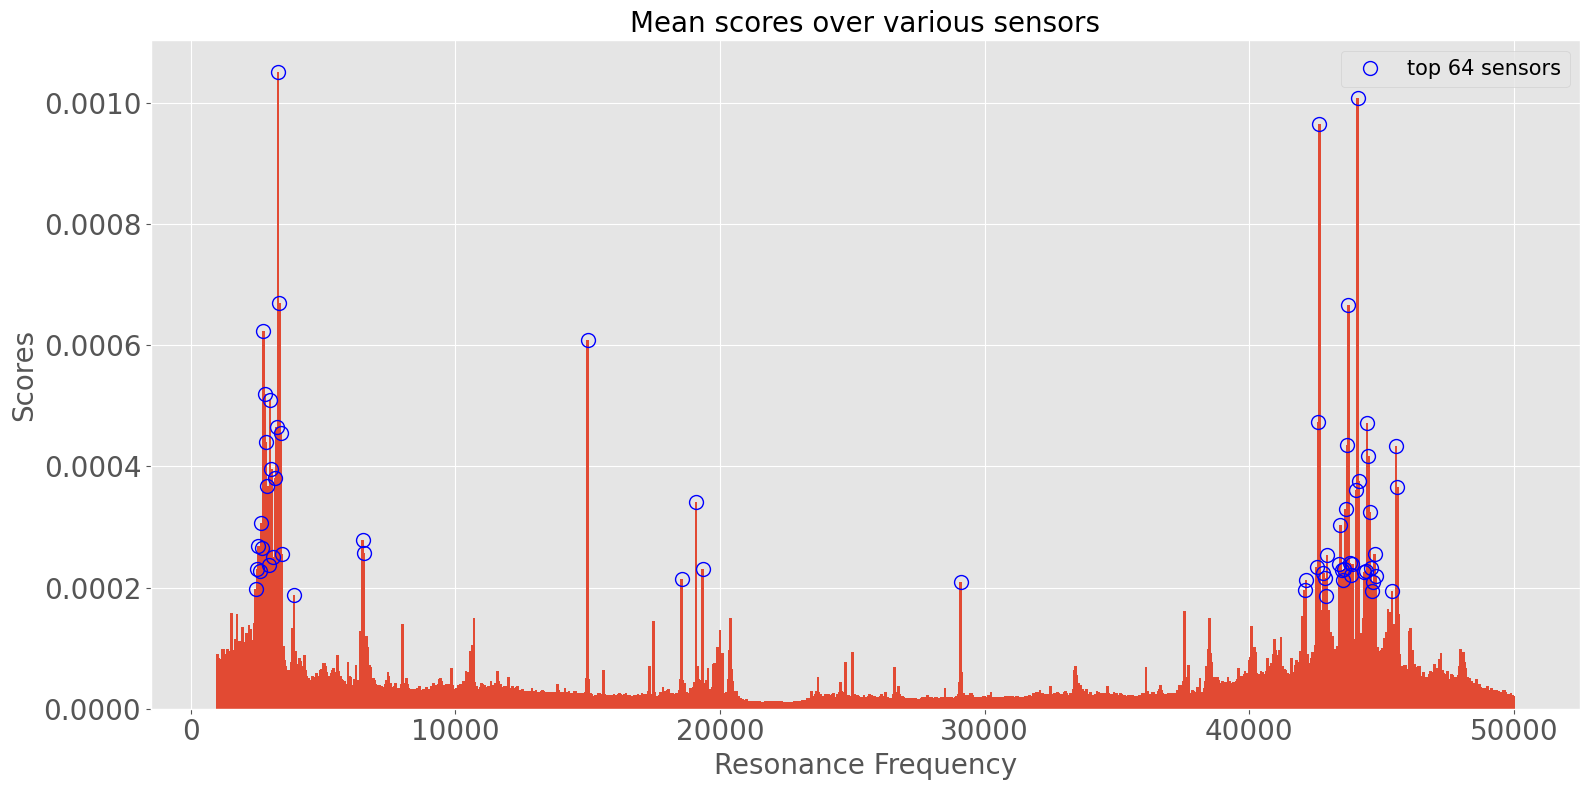

In [53]:
plt.figure(figsize=(16,8))
plt.bar(x=test_df['freq'], height=test_df['mean'], width=100)
plt.plot(
    test_df.sort_values(by="mean", ascending=False)["freq"][:64],
    test_df.sort_values(by="mean", ascending=False)["mean"][:64],
    'o',
    markersize=10,
    markeredgewidth=1,
    markerfacecolor='none',
    label="top 64 sensors",
    color='blue'
)
plt.xlabel("Resonance Frequency", fontsize=20)
plt.ylabel("Scores", fontsize=20)
plt.title("Mean scores over various sensors", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.legend(fontsize=15, loc="upper right")
plt.show()

In [54]:
np.array(test_df.sort_values(by="mean", ascending=False)["freq"][:64])

array([ 3300, 44100, 42650,  3350, 43750,  2750, 15000,  2800,  3000,
       42600, 44450,  3250,  3400,  2850, 43700, 45550, 44500,  3050,
        3200, 44150,  2900, 45600, 44050, 19100, 43650, 44550,  2650,
       43450,  6500,  2550,  2700,  6550, 44750,  3450, 42950,  3100,
       43800, 43900, 43400,  2950, 42550, 44600, 19350, 43600,  2500,
       43500, 44400,  2600, 44350, 42800, 43850, 44800, 42850, 18550,
       42150, 43550, 44700, 29100,  2450, 42100, 45400, 44650,  3900,
       42900])